In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

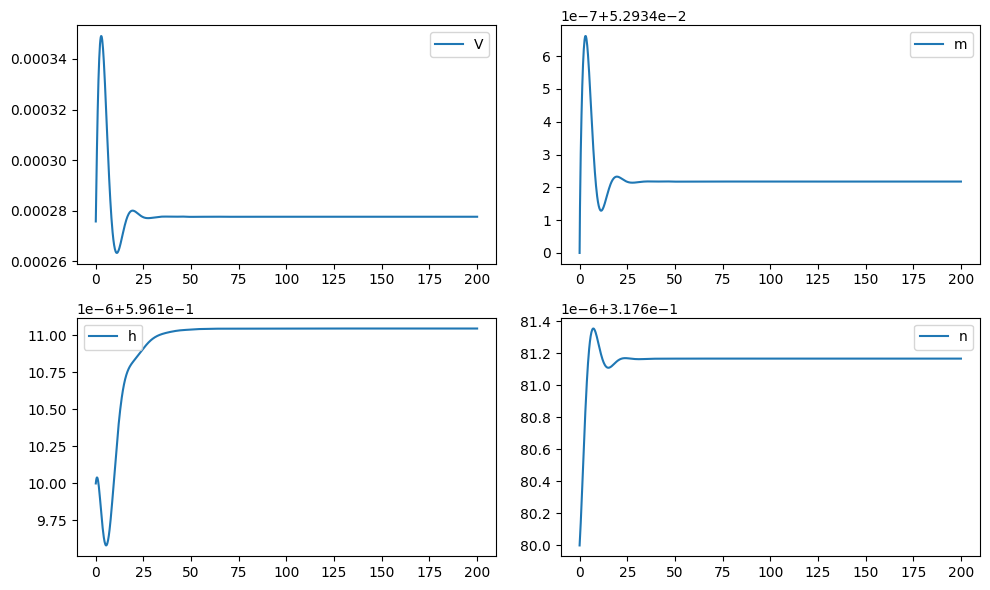

In [16]:
## EX 1

def HH(y, t, T, T_rest, I_app, current_type):
    V, m, h, n = y

    alpha_m = 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)  
    beta_m = 4 * np.exp(-V / 18)

    alpha_h = 0.07 * np.exp(-V / 20)
    beta_h = 1 / (np.exp((30 - V) / 10) + 1)

    alpha_n = 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)  
    beta_n = 0.125 * np.exp(-V / 80)

    I_na = g_Na * m**3 * h * (V - V_Na) 
    I_k = g_K * n**4 * (V - V_K)
    I_leak = g_L * (V - V_L)
    
    if current_type == "impulse":
        I_app = I_app if t < T else 0  # Impulso singolo
    elif current_type == "ciclo":
        I_app = I_app if t % (T_rest + T) < T else 0  # Impulso ciclico
    elif current_type == "constant":
        I_app = I_app  # Corrente continua
    elif current_type == "test":
        I_app = t/2
    else:
        I_app = 0 

    dVdt = -(I_na + I_k + I_leak - I_app) / C
    dmdt = alpha_m * (1 - m) - beta_m * m
    dhdt = alpha_h * (1 - h) - beta_h * h
    dndt = alpha_n * (1 - n) - beta_n * n

    return [dVdt, dmdt, dhdt, dndt]

# Parametri
C, g_Na, g_K, g_L, V_Na, V_K, V_L, I_app = 1, 120, 36, 0.3, 115, -12, 10.6, 0
T = 0 #ms 
T_rest = 0
#shift = 20
t = np.linspace(0, 200, 1000)

y0 = [2.7570 * 10**(-4), 5.2934 * 10**(-2), 5.9611 * 10**(-1), 3.1768 * 10**(-1)]

solution = odeint(HH, y0, t, args = (T, T_rest, I_app, "impulse" ))

fig, axes = plt.subplots(2, 2, figsize=(10, 6))

axes[0][0].plot(t, solution[:, 0], label="V")
axes[0][1].plot(t, solution[:, 1], label="m")
axes[1][0].plot(t, solution[:, 2], label="h")
axes[1][1].plot(t, solution[:, 3], label="n")

axes[0][0].legend()
axes[0][1].legend()
axes[1][0].legend()
axes[1][1].legend()

plt.tight_layout()

plt.show()


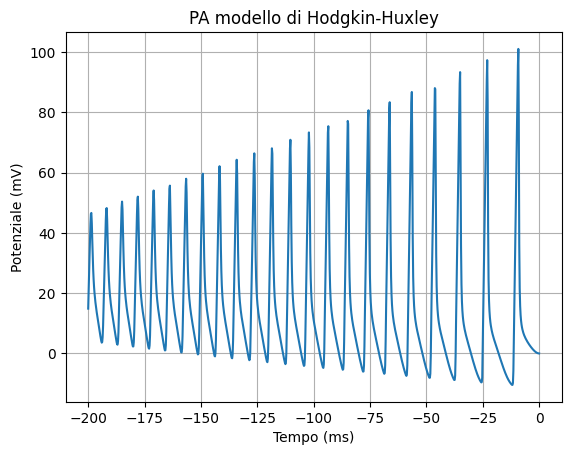

Ampiezza Action Potentials: [106.9336185   90.11196254  74.44820425  59.96032687  47.4807803 ]


In [ ]:
test_sol = odeint(HH, y0, t, args = (T, T_rest, I_app, "test" ))
V_test = test_sol[:,0]
plt.plot(-t, V_test, label="Potenziale di membrana (mV)")
plt.grid(True)
plt.xlabel("Tempo (ms)")
plt.ylabel("Potenziale (mV)")
plt.title("PA modello di Hodgkin-Huxley")
plt.show()

from scipy.signal import find_peaks

peaks, _ = find_peaks(V_test, height=0)  
minima, _ = find_peaks(-V_test, height= -60)
n_peaks = [1, 5, 10, 15, 20]  
peak_values = [V_test[peaks[i]] if i < len(peaks) else np.nan for i in n_peaks]
min_values = np.array([V_test[minima[minima > peaks[i]][0]] if (i < len(peaks) and len(minima[minima > peaks[i]]) > 0) else np.nan for i in n_peaks])
V_rest = [-65, -65, -65, -65, -65]
Amplitude = peak_values - min_values
print ("Ampiezza Action Potentials:", Amplitude)


## COMMENTO ESITO_
# unità di misura asse x invertita: definend I_app = t/2 , l'output è una serie di PA che decrescono progressivamente 
# in ampiezza. Cosa poco logica poiché lo stimolo applicato per definizione aumenta con il tempo.
# quindi per t <<, A << e cresce linearmente con esso. 

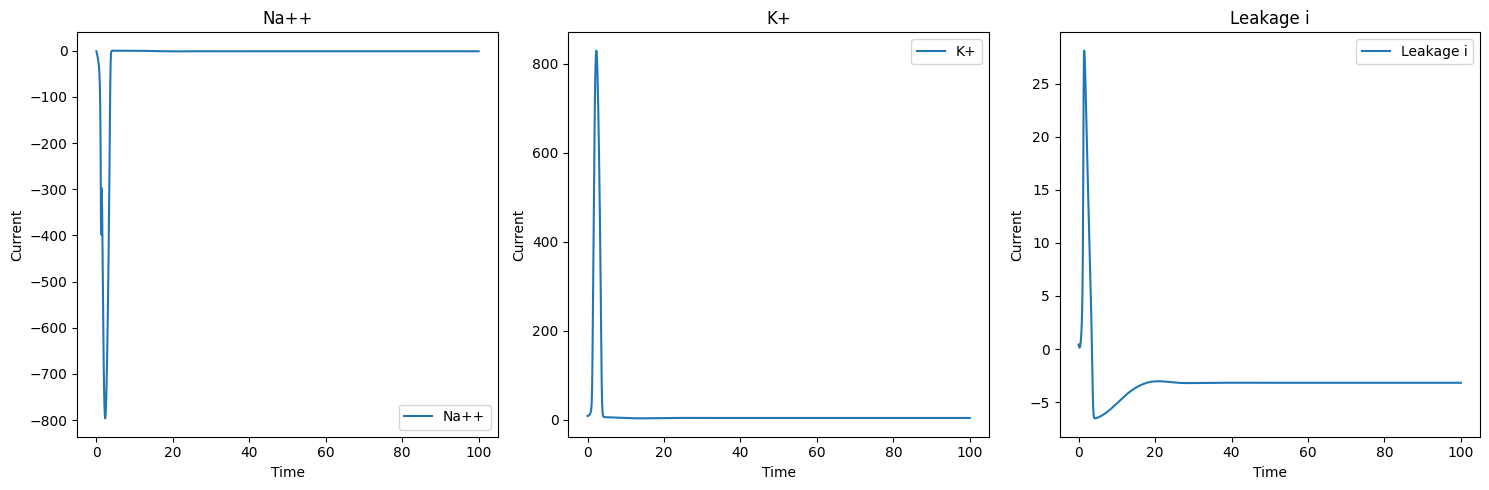

row: [6.506      6.13210613 5.88997597 5.75844608 5.70882423]
row: [9.         8.48866307 8.19494303 8.1080578  8.19310177]
row: [2.         1.88323848 1.7965098  1.72986979 1.67581489]


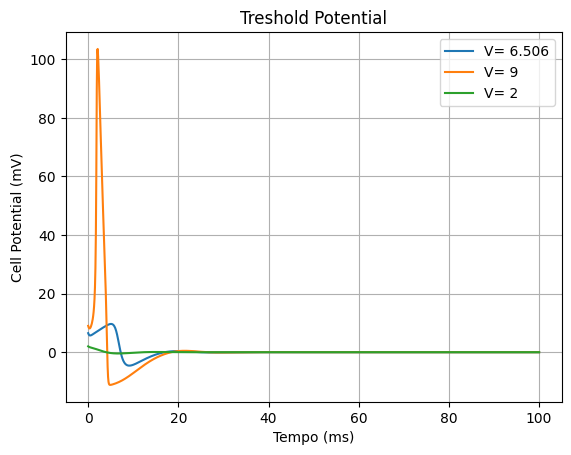

In [58]:
## EX 2: effetto soglia 
m =  solution[:, 1]
h = solution[:, 2]
V = solution[:, 0]
n = solution[:, 3 ]

I_na = g_Na * m **3 * h * ( V - V_Na) 
I_k = g_K * n **4 * (V - V_K)
I_leak = g_L * (V- V_L)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 riga, 3 colonne

axes[0].plot(t, I_na, label="Na++")
axes[1].plot(t, I_k, label="K+")
axes[2].plot(t, I_leak, label="Leakage i")

for ax, label in zip(axes, ["Na++", "K+", "Leakage i"]):
    ax.set_title(label)
    ax.set_xlabel("Time")
    ax.set_ylabel("Current")
    ax.legend()

plt.tight_layout()
plt.show()

V0_test =  [6.506, 9, 2]
T_rest, I_app = 0,0
for i in V0_test:
    y0[0] = i
    sol = odeint(HH, y0, t, args=(T, T_rest, I_app, "impulse" ))

    if sol[:, 0][0] > - 50: 
        plt.plot(t, sol[:, 0], label=(f'V= {i}'))
        plt.legend()
        print ("row:" , sol[:,0][0:5])

plt.title("Treshold Potential")
plt.xlabel("Tempo (ms)")
plt.ylabel("Cell Potential (mV)")
plt.legend()
plt.grid()
plt.show()

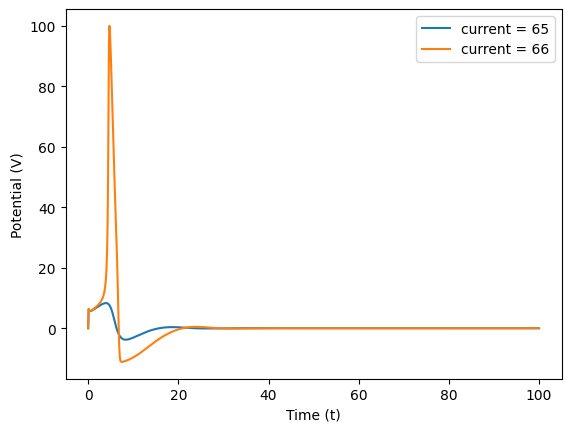

In [56]:
# EX 3 
I_app_list = [65, 66]  ## Iapp <= 65 non si ha un PA
T= 0.1 #ms 
y0_ex3 =  [2.7570* 10**(-4), 5.2934* 10**(-2), 5.9611* 10**(-1), 3.1768* 10**(-1)]


for I_app in I_app_list:
    sol_3 = odeint(HH, y0_ex3, t, args = (T, T_rest, I_app, "impulse"))
    plt.plot(t, sol_3[:, 0], label= f"current = {I_app}")
    plt.xlabel("Time (t)")
    plt.ylabel("Potential (V)")
    plt.legend()
plt.show()

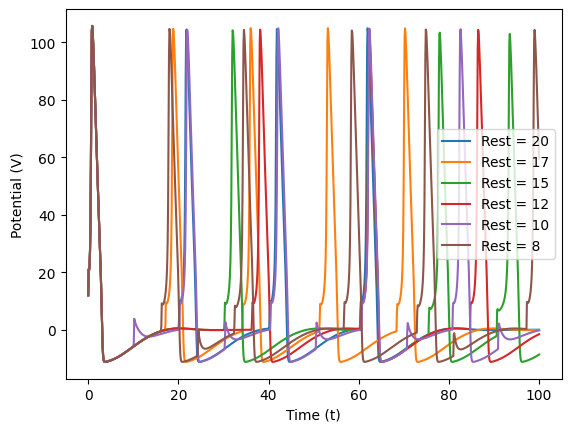

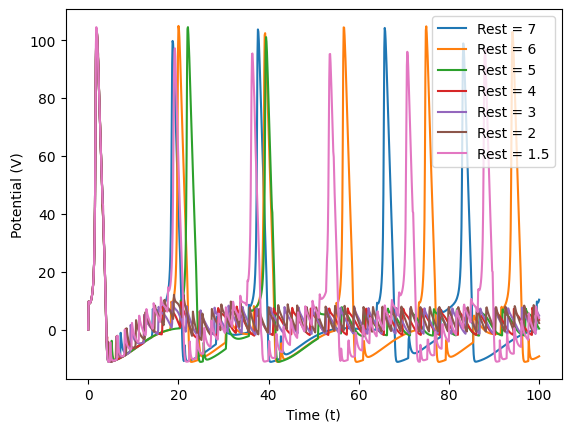

In [57]:
## EX 4 Refrattarietà


y0 = [12, 5.2934 * 10**(-2), 5.9611 * 10**(-1), 3.1768 * 10**(-1)]
I_app = 100
t= np.linspace(0, 100, 1000)
T = 0.1

rest_list1 = (20, 17, 15, 12, 10, 8) 
rest_list2 = (7, 6, 5, 4, 3, 2, 1.5)

for T_rest in rest_list1 :
    sol_3 = odeint(HH, y0, t, args = (T, T_rest, I_app, "ciclo"))
    plt.plot(t, sol_3[:, 0], label= f"Rest = {T_rest}")
    plt.xlabel("Time (t)")
    plt.ylabel("Potential (V)")
    plt.legend()
plt.show()

for T_rest in rest_list2 :
    sol_3 = odeint(HH, y0_ex3, t, args = (T, T_rest, I_app, "ciclo"))
    plt.plot(t, sol_3[:, 0], label= f"Rest = {T_rest}")
    plt.xlabel("Time (t)")
    plt.ylabel("Potential (V)")
    plt.legend()
plt.show()


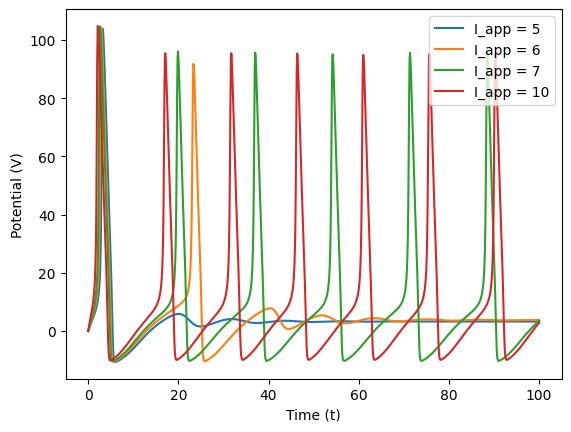

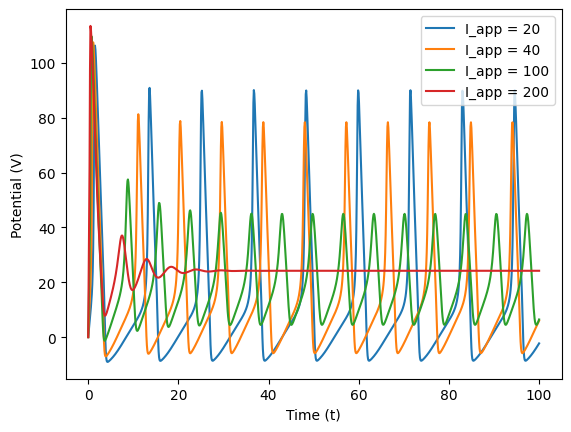

In [49]:
## EX 5  I_app continua TRENI 

I_app = [5 , 6, 7, 10]
I_app2 = [20, 40 , 100, 200]
T_rest = 0
T= 100

for i in I_app:
    sol_3 = odeint(HH, y0_ex3, t, args = (T, T_rest, i, "constant"))
    plt.plot(t, sol_3[:, 0], label= f"I_app = {i}")
    plt.xlabel("Time (t)")
    plt.ylabel("Potential (V)")
    plt.legend()
plt.show()

for i in I_app2:
    sol_3 = odeint(HH, y0_ex3, t, args = (T, T_rest, i, "constant" ))
    plt.plot(t, sol_3[:, 0], label= f"I_app = {i}")
    plt.xlabel("Time (t)")
    plt.ylabel("Potential (V)")
    plt.legend()
plt.show()

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

# Set random seed (for reproducibility)
np.random.seed(1000)

tmin, tmax = 0.0, 50.0
gK, gNa, gL = 36.0, 120.0, 0.3
Cm = 1.0
VK, VNa, Vl = -12.0, 115.0, 10.613
T = np.linspace(tmin, tmax, 10000)

# Potassium ion-channel rate functions

def alpha_n(Vm):
    return (0.01 * (10.0 - Vm)) / (np.exp(1.0 - (0.1 * Vm)) - 1.0)

def beta_n(Vm):
    return 0.125 * np.exp(-Vm / 80.0)

# Sodium ion-channel rate functions

def alpha_m(Vm):
    return (0.1 * (25.0 - Vm)) / (np.exp(2.5 - (0.1 * Vm)) - 1.0)

def beta_m(Vm):
    return 4.0 * np.exp(-Vm / 18.0)

def alpha_h(Vm):
    return 0.07 * np.exp(-Vm / 20.0)

def beta_h(Vm):
    return 1.0 / (np.exp(3.0 - (0.1 * Vm)) + 1.0)
  
# n, m, and h steady-state values

def n_inf(Vm=0.0):
    return alpha_n(Vm) / (alpha_n(Vm) + beta_n(Vm))

def m_inf(Vm=0.0):
    return alpha_m(Vm) / (alpha_m(Vm) + beta_m(Vm))

def h_inf(Vm=0.0):
    return alpha_h(Vm) / (alpha_h(Vm) + beta_h(Vm))
  
def Id(t):
    if 0.0 < t < 1.0:
        return 150.0
    elif 10.0 < t < 11.0:
        return 50.0
    return 0.0

  
# Compute derivatives
def compute_derivatives(y, t0):
    dy = np.zeros((4,))
    
    Vm = y[0]
    n = y[1]
    m = y[2]
    h = y[3]
    
    # dVm/dt
    GK = (gK / Cm) * np.power(n, 4.0)
    GNa = (gNa / Cm) * np.power(m, 3.0) * h
    GL = gL / Cm
    
    dy[0] = (Id(t0) / Cm) - (GK * (Vm - VK)) - (GNa * (Vm - VNa)) - (GL * (Vm - Vl))
    
    # dn/dt
    dy[1] = (alpha_n(Vm) * (1.0 - n)) - (beta_n(Vm) * n)
    
    # dm/dt
    dy[2] = (alpha_m(Vm) * (1.0 - m)) - (beta_m(Vm) * m)
    
    # dh/dt
    dy[3] = (alpha_h(Vm) * (1.0 - h)) - (beta_h(Vm) * h)
    
    return dy
  
# State (Vm, n, m, h)
Y = np.array([0.0, n_inf(), m_inf(), h_inf()])

# Solve ODE system
# Vy = (Vm[t0:tmax], n[t0:tmax], m[t0:tmax], h[t0:tmax])
Vy = odeint(compute_derivatives, Y, T)

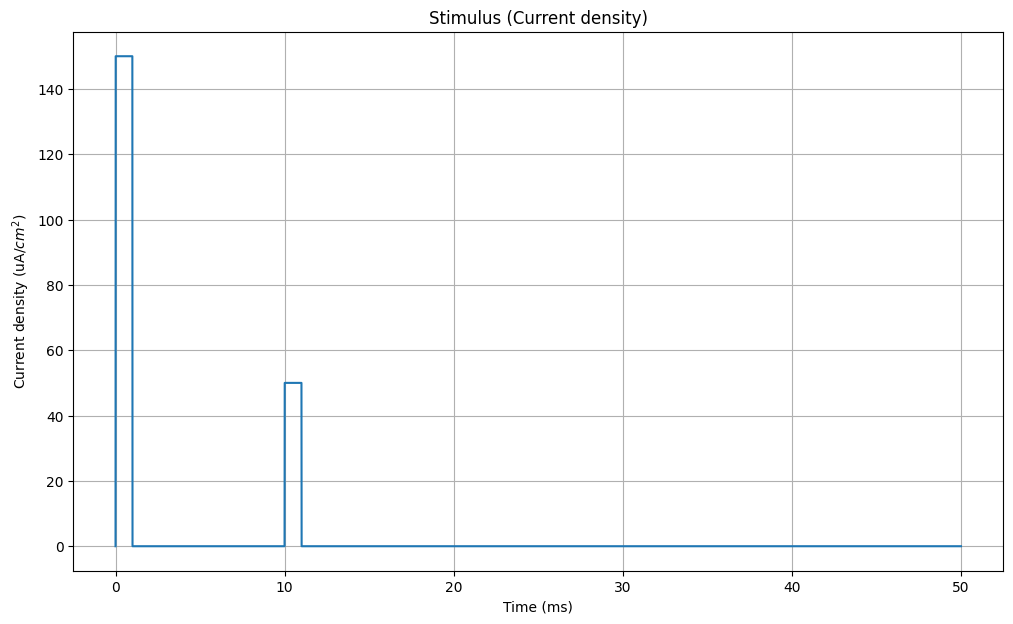

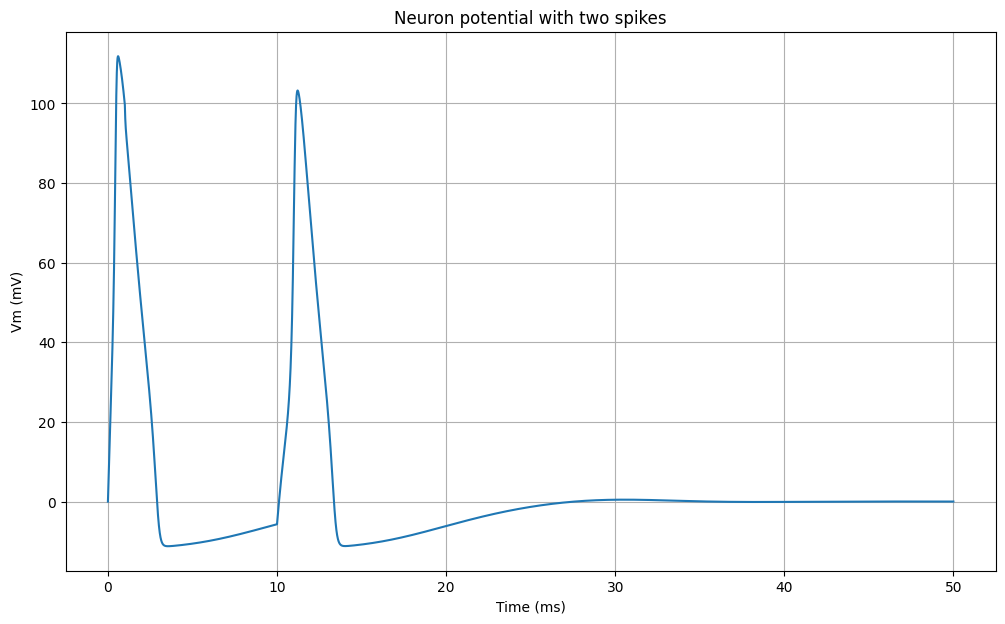

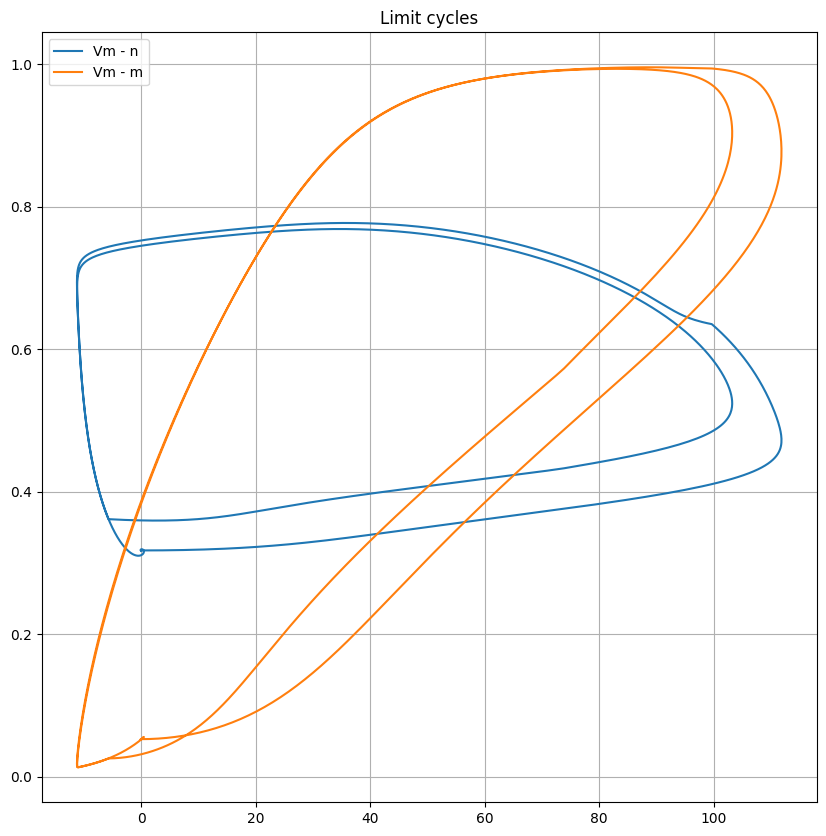

In [59]:
# Input stimulus
Idv = [Id(t) for t in T]

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(T, Idv)
ax.set_xlabel('Time (ms)')
ax.set_ylabel(r'Current density (uA/$cm^2$)')
ax.set_title('Stimulus (Current density)')
plt.grid()

# Neuron potential
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(T, Vy[:, 0])
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Vm (mV)')
ax.set_title('Neuron potential with two spikes')
plt.grid()

# Trajectories with limit cycles
fig, ax = plt.subplots(figsize=(10, 10))
ax.plot(Vy[:, 0], Vy[:, 1], label='Vm - n')
ax.plot(Vy[:, 0], Vy[:, 2], label='Vm - m')
ax.set_title('Limit cycles')
ax.legend()
plt.grid()